In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("../Datos/trade-register-1.csv",encoding='utf-8',sep=",")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29507 entries, 0 to 29506
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       29503 non-null  object 
 1   Supplier                        29507 non-null  object 
 2   Year of order                   29507 non-null  float64
 3                                   15574 non-null  object 
 4   Number ordered                  29217 non-null  float64
 5    .1                             12297 non-null  object 
 6   Weapon designation              29503 non-null  object 
 7   Weapon description              29503 non-null  object 
 8   Number delivered                29503 non-null  float64
 9    .2                             16515 non-null  object 
 10  Year(s) of delivery             28346 non-null  object 
 11  status                          29503 non-null  object 
 12  Comments                        

In [11]:
df.head(20)

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,Russia,2002.0,NaN,3.0,NaN,Mi-17,transport helicopter,3.0,NaN,2002,Second hand,Second-hand; aid,2.90,8.70,8.70
1,Afghanistan,Turkiye,2007.0,NaN,24.0,NaN,M-114 155mm,towed gun,24.0,NaN,2007,Second hand,Second-hand; aid,0.20,4.80,4.80
2,Afghanistan,United States,2004.0,?,188.0,?,M-113,armoured personnel carrier,188.0,?,2005,Second hand,Second-hand; aid; M-113A2 version; incl 15 M-5...,0.10,18.80,18.80
3,Afghanistan,United States,2016.0,NaN,53.0,NaN,S-70 Black Hawk,transport helicopter,53.0,?,2017; 2018; 2019; 2020,Second hand but modernized,Second-hand UH-60A modernized to UH-60A+ befor...,4.29,227.37,227.37
4,Afghanistan,Soviet Union,1973.0,?,100.0,?,T-62,tank,100.0,?,1975; 1976,New,NaN,1.80,180.00,180.00
5,Afghanistan,Soviet Union,1978.0,?,500.0,?,T-55,tank,500.0,?,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986...,Second hand,Second-hand; aid,0.50,250.00,250.00
6,Afghanistan,Soviet Union,1960.0,?,50.0,?,BM-13 132mm,multiple rocket launcher,50.0,?,1960; 1961,Second hand,Second-hand,0.08,4.00,4.00
7,Afghanistan,United States,2017.0,?,250.0,?,Paveway,guided bomb,250.0,?,2017; 2018; 2019,New,Paveway-2 version; for Super Tucano (A-29B) tr...,0.02,5.00,5.00
8,Afghanistan,United States,2012.0,NaN,71.0,NaN,M-1117 Guardian,armoured personnel carrier,71.0,?,2014,New,$79 m deal; MSFV version,0.40,28.40,28.40
9,Afghanistan,United States,2011.0,NaN,240.0,NaN,M-1117 Guardian,armoured personnel carrier,240.0,?,2012; 2013,New,$257 m deal; MSFV version; incl command post; ...,0.40,96.00,96.00


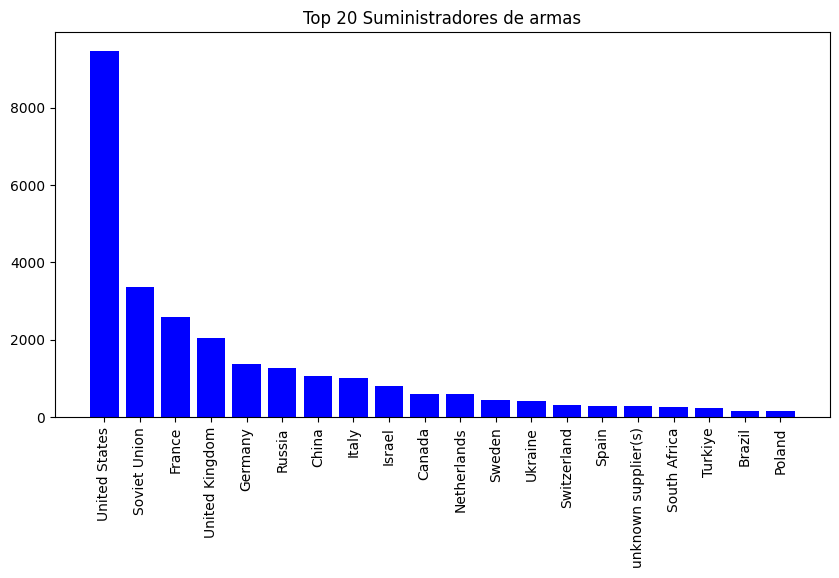

In [ ]:
cuenta_suppliers=df["Supplier"].value_counts().head(20)
plt.figure(figsize=(10,5))
plt.bar(cuenta_suppliers.index, cuenta_suppliers.values, color="blue")
plt.xticks(rotation=90)
plt.title("Top 20 Suministradores de armas")
plt.show()

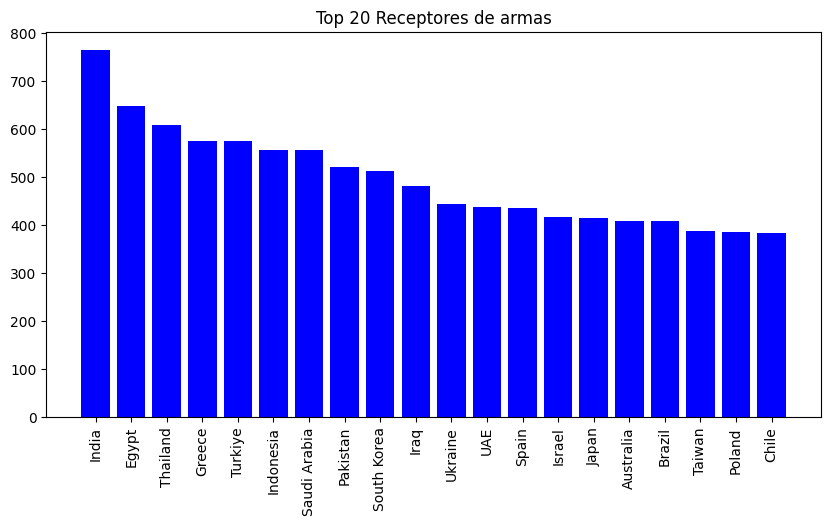

In [22]:
cuenta_recipient=df["Recipient"].value_counts().head(20)
plt.figure(figsize=(10,5))
plt.bar(cuenta_recipient.index, cuenta_recipient.values, color="blue")
plt.xticks(rotation=90)
plt.title("Top 20 Receptores de armas")
plt.show()

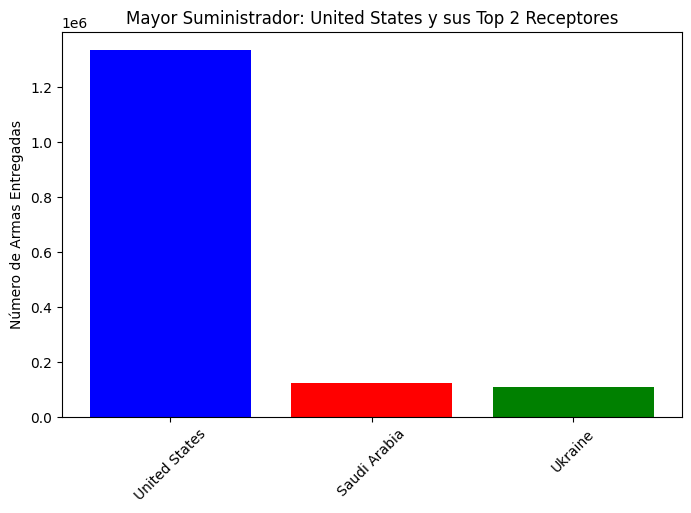

In [4]:
# Filtrar filas con Number delivered válido
df_filtered = df.dropna(subset=['Number delivered'])

# Encontrar el mayor suministrador por suma de Number delivered
supplier_totals = df_filtered.groupby('Supplier')['Number delivered'].sum().sort_values(ascending=False)
top_supplier = supplier_totals.index[0]
top_value = supplier_totals.iloc[0]

# Filtrar datos para el top supplier
supplier_data = df_filtered[df_filtered['Supplier'] == top_supplier]

# Encontrar los 2 países a los que más les suministra
recipient_totals = supplier_data.groupby('Recipient')['Number delivered'].sum().sort_values(ascending=False).head(2)

# Preparar datos para gráfica
labels = [top_supplier] + list(recipient_totals.index)
values = [top_value] + list(recipient_totals.values)

# Graficar
plt.figure(figsize=(8,5))
plt.bar(labels, values, color=['blue', 'red', 'green'])
plt.xticks(rotation=45)
plt.title(f"Mayor Suministrador: {top_supplier} y sus Top 2 Receptores")
plt.ylabel("Número de Armas Entregadas")
plt.show()

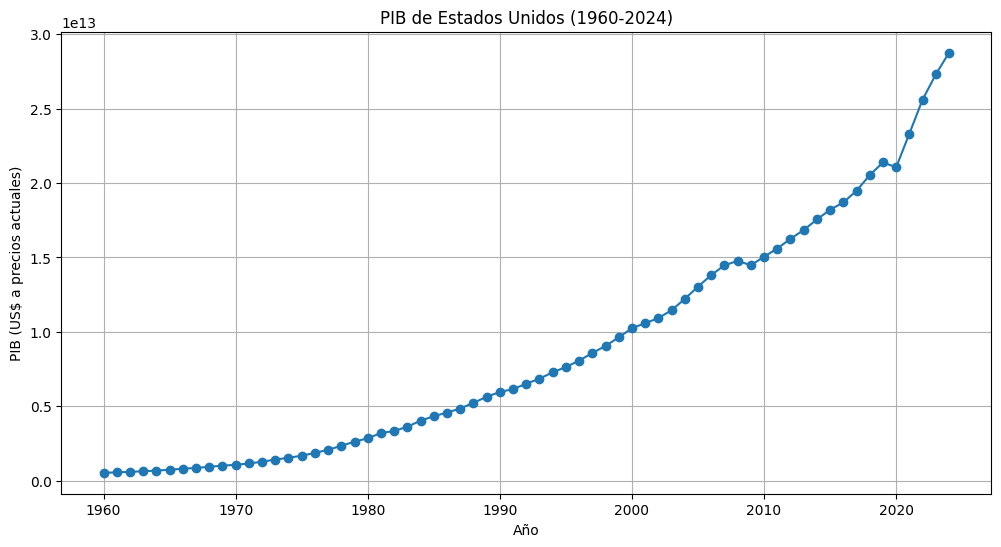

In [3]:
# Cargar datos de PIB
pib_df = pd.read_csv("../PIB/API_NY.GDP.MKTP.CD_DS2_es_csv_v2_3676.csv")

# Filtrar para Estados Unidos
us_row = pib_df[pib_df['Country Name'] == 'Estados Unidos']

# Obtener columnas de años (desde 1960 hasta 2024)
year_cols = [col for col in pib_df.columns if col.isdigit() and 1960 <= int(col) <= 2024]

# Extraer años y valores
years = [int(col) for col in year_cols]
values = us_row[year_cols].values.flatten()
values = pd.to_numeric(values, errors='coerce')

# Graficar
plt.figure(figsize=(12,6))
plt.plot(years, values, marker='o', linestyle='-')
plt.title("PIB de Estados Unidos (1960-2024)")
plt.xlabel("Año")
plt.ylabel("PIB (US$ a precios actuales)")
plt.grid(True)
plt.show()